In [39]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
    
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [40]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [42]:
df= df.fillna(df["TotalCharges"].mean())
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [43]:
df = df.drop(['customerID'],axis=1)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
def label_encod(dataframe_series):
    if dataframe_series.dtype == 'object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [45]:
df = df.apply(lambda x : label_encod(x))
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [46]:
len(df[df['tenure']==0])

11

In [47]:
df=df.drop(labels = df[df['tenure']==0].index,axis = 0 )

In [48]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [49]:
X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [50]:
X_train , X_test ,y_train, y_test = train_test_split(X,y,test_size=0.30 , random_state = 40 , stratify = y)

In [51]:
def distplot(feutare , frame , color = 'r'):
    sns.set_context('notebook')
    plt.figure(figsize=(8,3))
    plt.title(f"Расприделение {feutare}")
    ax = sns.histplot(frame[feutare],color = color,kde=True)

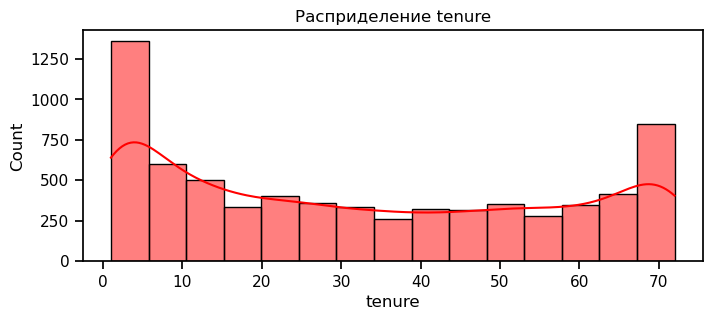

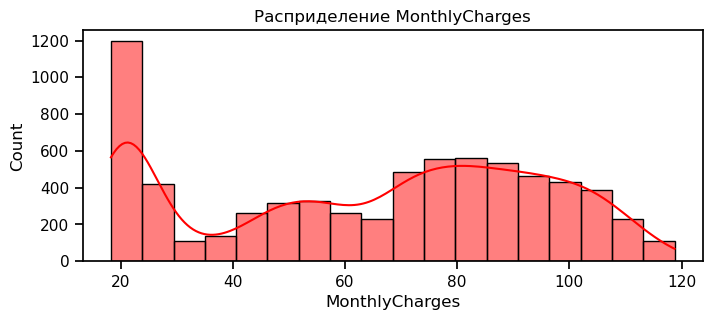

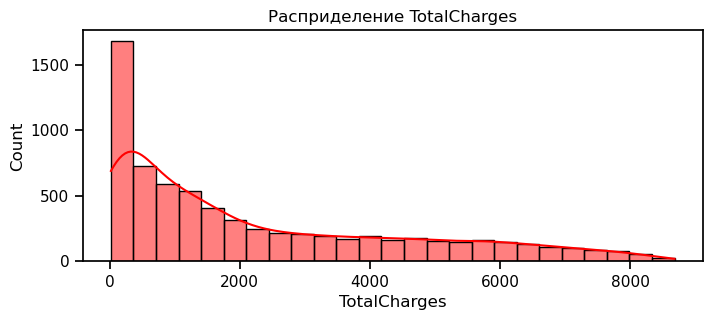

In [52]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

In [53]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


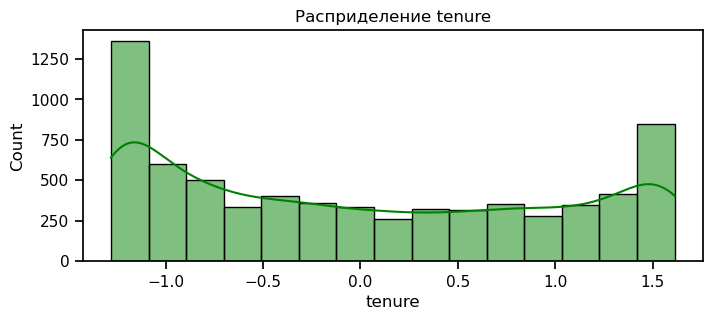

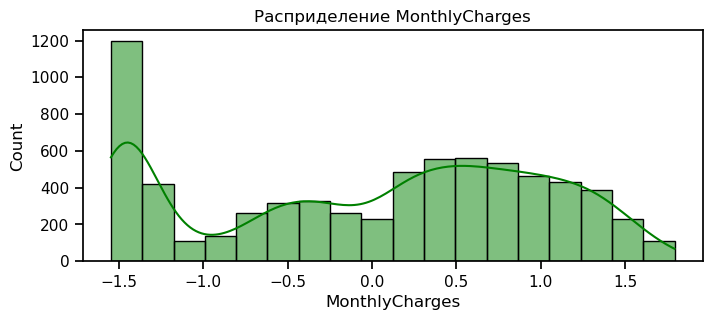

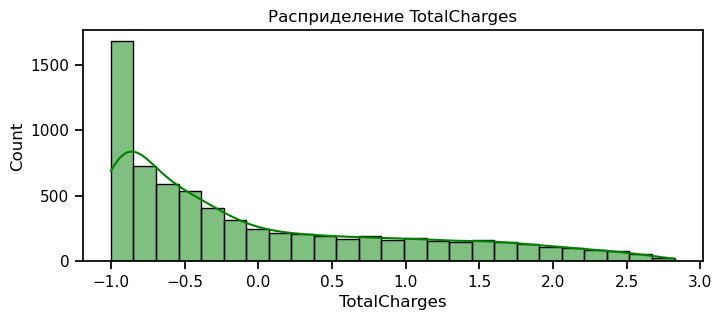

In [54]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),columns =num_cols )
for feat in numerical_cols: distplot(feat, df_std, color='green')


In [55]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])


In [56]:
def save_model(name , model):
    with open(f'../models/{name}.pkl', 'wb') as file:
        pickle.dump(model, file)

In [57]:
lr_model = LogisticRegression()
lr_model.fit(X_train , y_train )

accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.8085308056872038


In [58]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.58      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.74      0.75      2110
weighted avg       0.80      0.81      0.80      2110



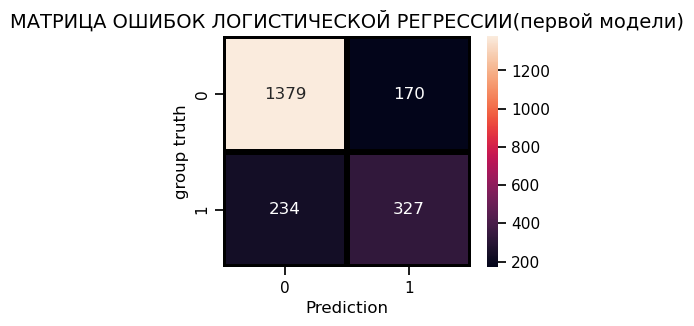

In [59]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("МАТРИЦА ОШИБОК ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ(первой модели)",fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('group truth')
plt.savefig('../images/first model CONFUSION MATRIX.png') 
plt.show()

AUC: 0.86


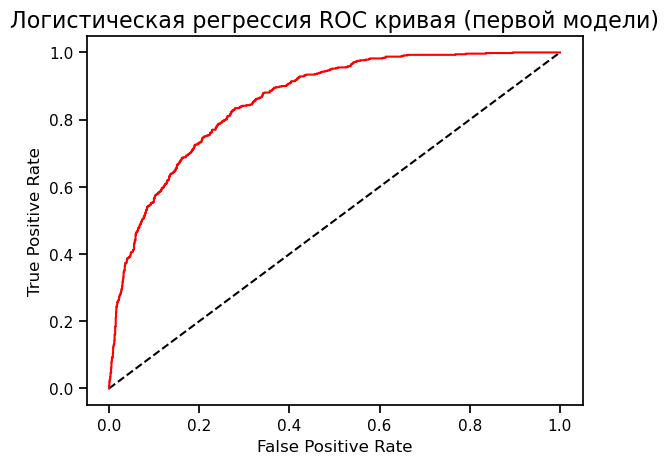

In [60]:
y_pred_prob = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Логистическая регрессия ROC кривая (первой модели)',fontsize=16)
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.2f}")
plt.savefig('../images/ROC Curve.png') 
plt.show()

In [61]:
save_model("first_model",lr_model)

In [62]:
lr_model2 = LogisticRegression(class_weight={0: 1, 1: 3}, random_state=42)
lr_model2.fit(X_train , y_train )

accuracy_lr2 = lr_model2.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr2)

Logistic Regression accuracy is : 0.7350710900473933


In [63]:
lr2_pred= lr_model2.predict(X_test)
report = classification_report(y_test,lr2_pred)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1549
           1       0.50      0.84      0.63       561

    accuracy                           0.74      2110
   macro avg       0.71      0.77      0.71      2110
weighted avg       0.81      0.74      0.75      2110



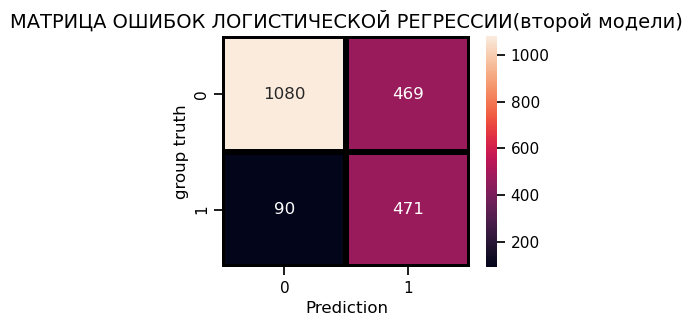

In [64]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr2_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("МАТРИЦА ОШИБОК ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ(второй модели)",fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('group truth')
plt.savefig('../images/second model CONFUSION MATRIX.png') 

plt.show()


AUC: 0.86


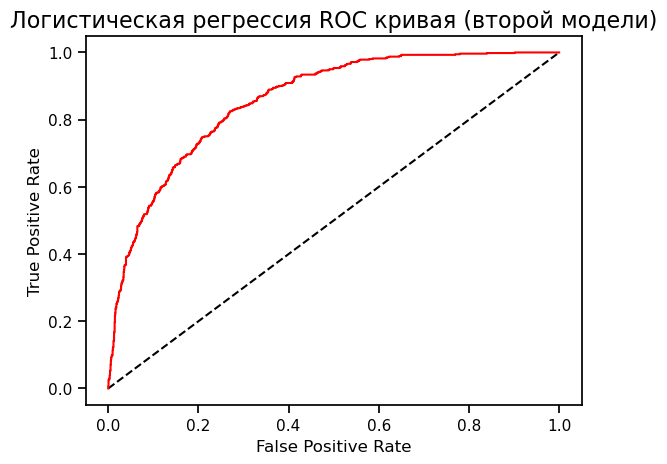

In [65]:
y_pred_prob = lr_model2.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Логистическая регрессия ROC кривая (второй модели)',fontsize=16)
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.2f}")
plt.show()

In [66]:
save_model("second_model",lr_model2)

<h2>Анализ эффективности моделей прогнозирования оттока</h2>

<h4>1.Сравнение производительности моделей</h4>
Первая модель демонстрирует общую точность 81% против 74% у второй модели. Первая модель показывает сбалансированные результаты: точность прогнозирования нелояльных клиентов (класс 0) составляет 85% при полноте 89%, что означает надежную идентификацию лояльных клиентов. Вторая модель жертвует общей точностью ради лучшей выявляемости оттока.

<h4>2.Выявление оттока клиентов (класс 1)</h4>
Вторая модель показывает значительно лучшую полноту (recall) для класса оттока: 84% против 58% у первой модели. Это означает, что вторая модель выявляет на 26% больше клиентов, склонных к оттоку. Однако точность (precision) второй модели для этого класса составляет всего 50% против 66% у первой модели, что указывает на большее количество ложных срабатываний.

<h4>3.Бизнес-последствия выбора модели</h4>
Первая модель минимизирует ложные срабатывания (170 случаев против 469 у второй модели), что снижает затраты на ненужные retention-кампании для лояльных клиентов. Вторая модель пропускает значительно меньше реальных случаев оттока (90 случаев против 234 у первой модели), что позволяет сохранить больше клиентов, но требует больших инвестиций в программы удержания из-за высокого уровня ложных срабатываний.

<h4>4.Рекомендации по выбору модели</h4>
<ul>
<li>При ограниченном бюджете на удержание клиентов рекомендуется первая модель как более экономически эффективная</li>
<li>При приоритете максимального сохранения клиентской базы и возможности работы с большим объемом лидов предпочтительна вторая модель</li>
<li>Для оптимизации затрат рекомендуется использовать первую модель с последующей ручной валидацией сомнительных случаев</li>
</ul>